Analysis of 380 Premier League 2025/26 matches using Python (pandas, matplotlib). Source: football-data.co.uk

The table calculated from match results matches the official final standings.

In [1]:
import pandas as pd

df = pd.read_csv("E0.csv")
print(df.shape)
df[["Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR"]].head()

(380, 132)


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR
0,15/08/2025,Liverpool,Bournemouth,4,2,H
1,16/08/2025,Aston Villa,Newcastle,0,0,D
2,16/08/2025,Brighton,Fulham,1,1,D
3,16/08/2025,Sunderland,West Ham,3,0,H
4,16/08/2025,Tottenham,Burnley,3,0,H


Home vs away results

In [2]:
results = df["FTR"].value_counts(normalize=True) * 100
print(results.round(1))

FTR
H    42.6
A    30.0
D    27.4
Name: proportion, dtype: float64


Goals scored at home and away

                Home goals  Away goals  Difference
Newcastle               36          17          19
Fulham                  30          17          13
Man City                45          32          13
Arsenal                 41          30          11
Brentford               33          22          11
Wolves                  19           8          11
Man United              39          30           9
Leeds                   29          20           9
Sunderland              25          17           8
Aston Villa             32          24           8
Brighton                30          22           8
West Ham                27          19           8
Liverpool               34          29           5
Everton                 26          21           5
Bournemouth             29          29           0
Burnley                 18          20          -2
Crystal Palace          19          22          -3
Tottenham               22          26          -4
Chelsea                 26     

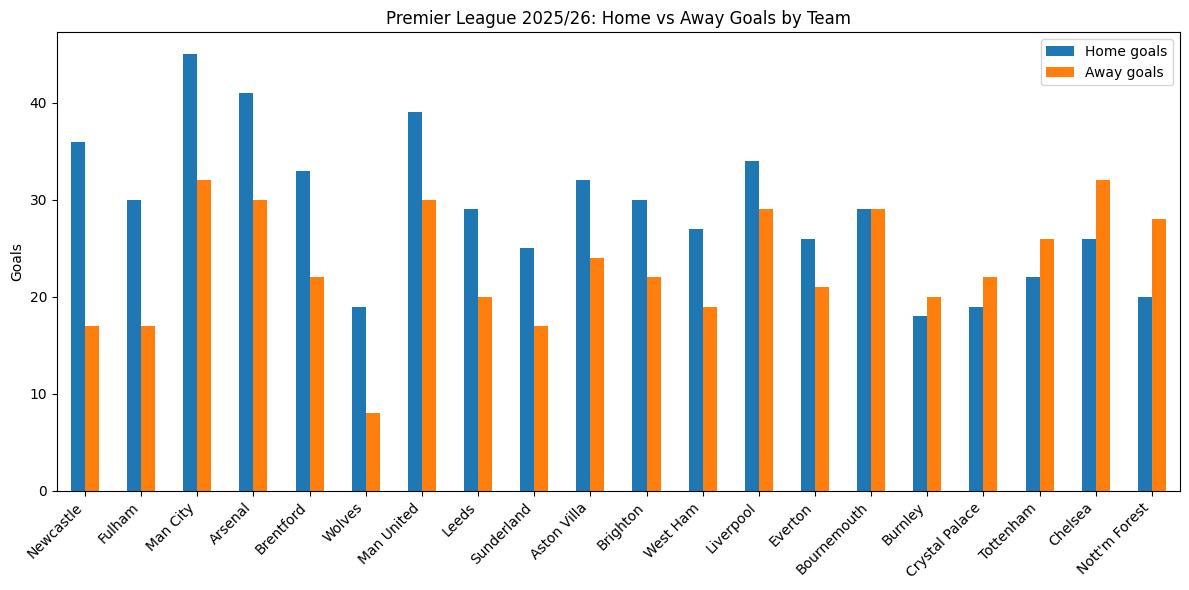

In [4]:
import matplotlib.pyplot as plt

home = df.groupby("HomeTeam")["FTHG"].sum()
away = df.groupby("AwayTeam")["FTAG"].sum()

goals = pd.DataFrame({"Home goals": home, "Away goals": away})
goals["Difference"] = goals["Home goals"] - goals["Away goals"]
goals = goals.sort_values("Difference", ascending=False)
print(goals)

goals[["Home goals", "Away goals"]].plot(kind="bar", figsize=(12, 6))
plt.title("Premier League 2025/26: Home vs Away Goals by Team")
plt.ylabel("Goals")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Rebuilding the league table

In [5]:
df["HomePts"] = df["FTR"].map({"H": 3, "D": 1, "A": 0})
df["AwayPts"] = df["FTR"].map({"H": 0, "D": 1, "A": 3})

home_pts = df.groupby("HomeTeam")["HomePts"].sum()
away_pts = df.groupby("AwayTeam")["AwayPts"].sum()

gf = df.groupby("HomeTeam")["FTHG"].sum().add(df.groupby("AwayTeam")["FTAG"].sum())
ga = df.groupby("HomeTeam")["FTAG"].sum().add(df.groupby("AwayTeam")["FTHG"].sum())

table = pd.DataFrame({"Points": home_pts + away_pts, "GF": gf, "GA": ga})
table["GD"] = table["GF"] - table["GA"]
table = table.sort_values(["Points", "GD", "GF"], ascending=False)
table.index.name = "Team"
print(table)

                Points  GF  GA  GD
Team                              
Arsenal             85  71  27  44
Man City            78  77  35  42
Man United          71  69  50  19
Aston Villa         65  56  49   7
Liverpool           60  63  53  10
Bournemouth         57  58  54   4
Sunderland          54  42  48  -6
Brighton            53  52  46   6
Brentford           53  55  52   3
Chelsea             52  58  52   6
Fulham              52  47  51  -4
Newcastle           49  53  55  -2
Everton             49  47  50  -3
Leeds               47  49  56  -7
Crystal Palace      45  41  51 -10
Nott'm Forest       44  48  51  -3
Tottenham           41  48  57  -9
West Ham            39  46  65 -19
Burnley             22  38  75 -37
Wolves              20  27  68 -41
